In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Rohith_A_P_Integrated_Uber_Traffic_Dataset.csv")

In [3]:
# Convert DateTime
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [4]:
df.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month,Is_Weekend,Peak_Hour,Temperature,Rainfall,Humidity,WindSpeed,Is_Holiday,Special_Event,Event_Impact
0,2015-01-11 00:00:00,1,15,20151101001,0,Sunday,1,1,0,26,0.0,84,11,0,0,Normal
1,2015-01-11 01:00:00,1,13,20151101011,1,Sunday,1,1,0,23,0.2,94,7,0,1,Normal
2,2015-01-11 02:00:00,1,10,20151101021,2,Sunday,1,1,0,32,0.0,63,7,0,0,Normal
3,2015-01-11 03:00:00,1,7,20151101031,3,Sunday,1,1,0,34,0.0,52,10,0,0,Normal
4,2015-01-11 04:00:00,1,9,20151101041,4,Sunday,1,1,0,30,0.0,64,9,0,0,Normal


In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1702/1168271076.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [6]:
# AGGREGATE TRAFFIC DATA

hourly_traffic = df.groupby(
    'Hour'
)['Vehicles'].mean().reset_index()

print(hourly_traffic)

    Hour   Vehicles
0      0  23.540648
1      1  19.654863
2      2  17.102743
3      3  14.847382
4      4  12.973067
5      5  12.173566
6      6  12.980050
7      7  14.703242
8      8  16.402993
9      9  19.379551
10    10  24.229925
11    11  27.495262
12    12  28.403990
13    13  25.588529
14    14  27.702743
15    15  27.650374
16    16  26.674314
17    17  26.648379
18    18  28.095262
19    19  29.854863
20    20  29.824938
21    21  28.202993
22    22  27.226933
23    23  25.635411


In [7]:
# PEAK HOUR IDENTIFICATION

peak_hour = hourly_traffic.loc[
    hourly_traffic['Vehicles'].idxmax()
]

print("\nPeak Traffic Hour:")
print(peak_hour)



Peak Traffic Hour:
Hour        19.000000
Vehicles    29.854863
Name: 19, dtype: float64


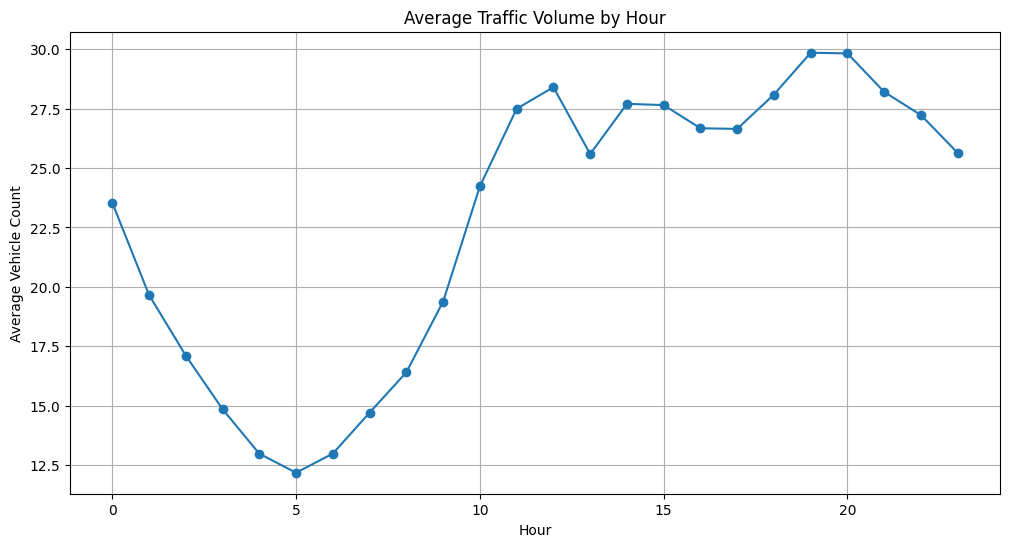

In [8]:
# LINE PLOT - TRAFFIC VS HOUR

plt.figure(figsize=(12,6))

plt.plot(
    hourly_traffic['Hour'],
    hourly_traffic['Vehicles'],
    marker='o'
)

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicle Count")

plt.grid(True)

plt.show()

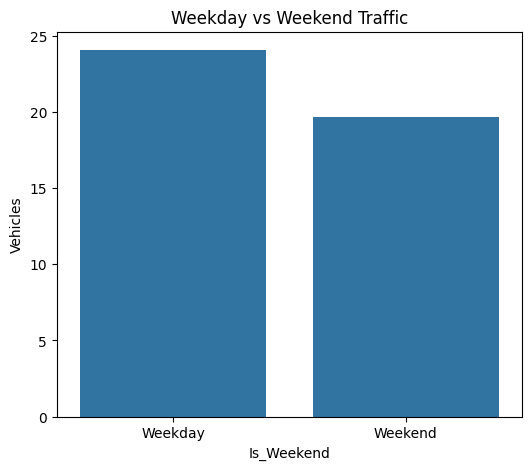

In [9]:
# WEEKDAY VS WEEKEND ANALYSIS

weekend_traffic = df.groupby(
    'Is_Weekend'
)['Vehicles'].mean().reset_index()

plt.figure(figsize=(6,5))

sns.barplot(
    x='Is_Weekend',
    y='Vehicles',
    data=weekend_traffic
)

plt.title("Weekday vs Weekend Traffic")

plt.xticks(
    [0,1],
    ['Weekday','Weekend']
)

plt.show()


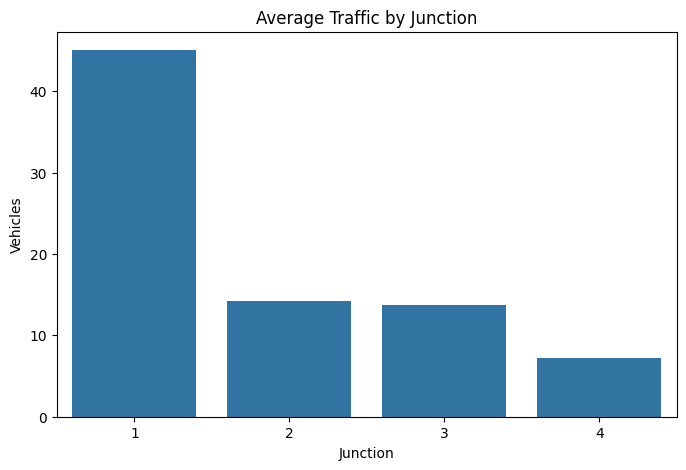

In [10]:
# JUNCTION ANALYSIS

junction_traffic = df.groupby(
    'Junction'
)['Vehicles'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x='Junction',
    y='Vehicles',
    data=junction_traffic
)

plt.title("Average Traffic by Junction")

plt.show()

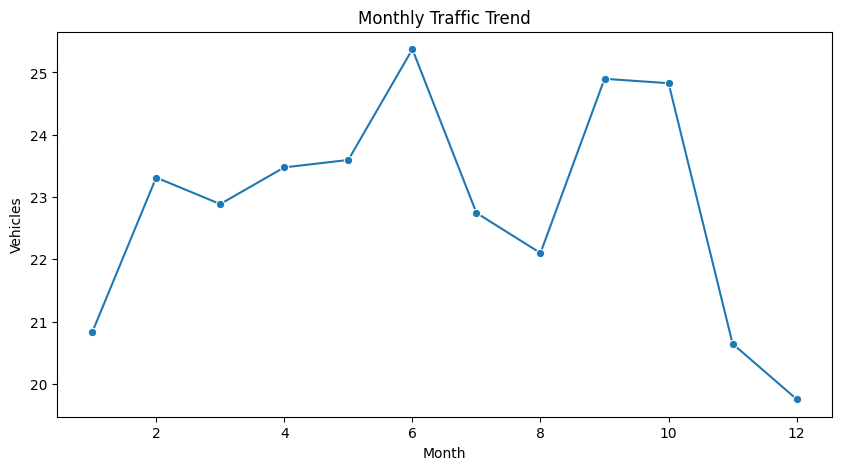

In [11]:
# MONTHLY TRAFFIC ANALYSIS

monthly_traffic = df.groupby(
    'Month'
)['Vehicles'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    x='Month',
    y='Vehicles',
    data=monthly_traffic,
    marker='o'
)

plt.title("Monthly Traffic Trend")

plt.show()

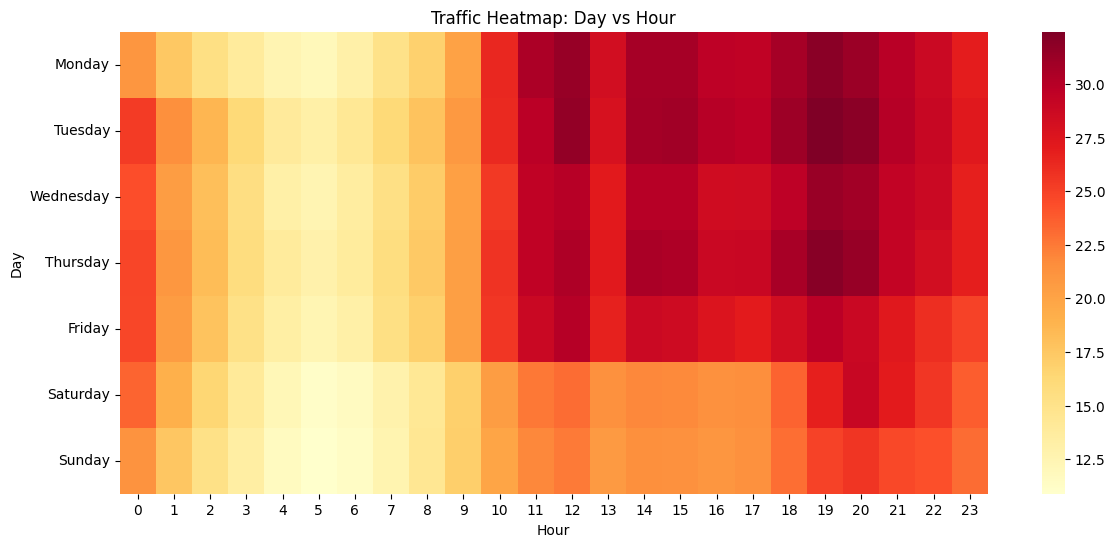

In [13]:
# 1. Create the pivot table as you did
heatmap_data = df.pivot_table(
    values='Vehicles',
    index='Day',
    columns='Hour',
    aggfunc='mean'
)

# 2. Define your desired order explicitly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 3. Reindex the pivot table rows to apply the order
heatmap_data = heatmap_data.reindex(day_order)

# 4. Plot the heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd'
)

plt.title("Traffic Heatmap: Day vs Hour")
plt.show()


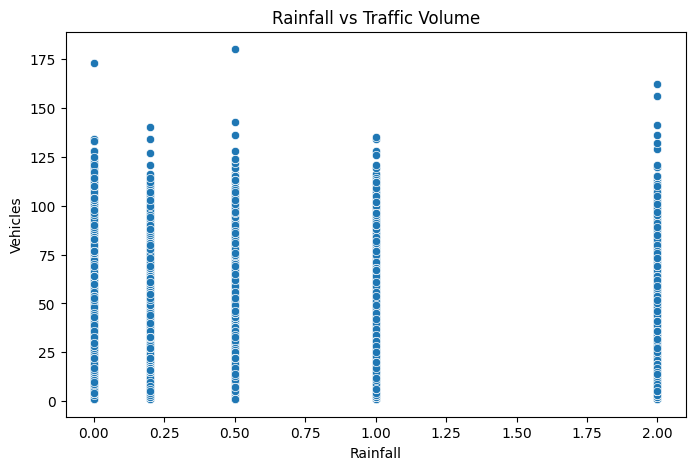

In [14]:
#WEATHER IMPACT ANALYSIS

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Rainfall',
    y='Vehicles',
    data=df
)

plt.title("Rainfall vs Traffic Volume")

plt.show()

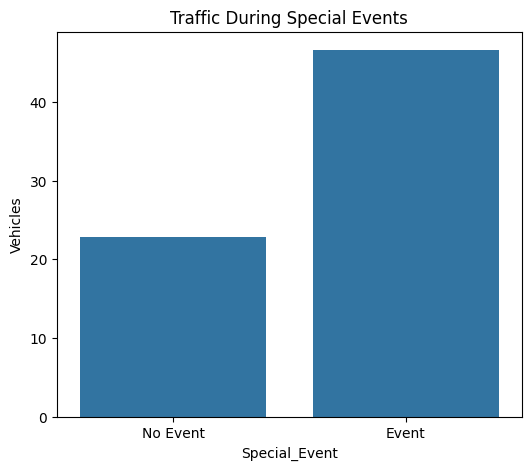

In [21]:
# EVENT IMPACT ANALYSIS

event_traffic = df.groupby(
    'Special_Event'
)['Vehicles'].mean().reset_index()

plt.figure(figsize=(6,5))

sns.barplot(
    x='Special_Event',
    y='Vehicles',
    data=event_traffic
)

plt.title("Traffic During Special Events")

plt.xticks(
    [0,1],
    ['No Event','Event']
)

plt.show()

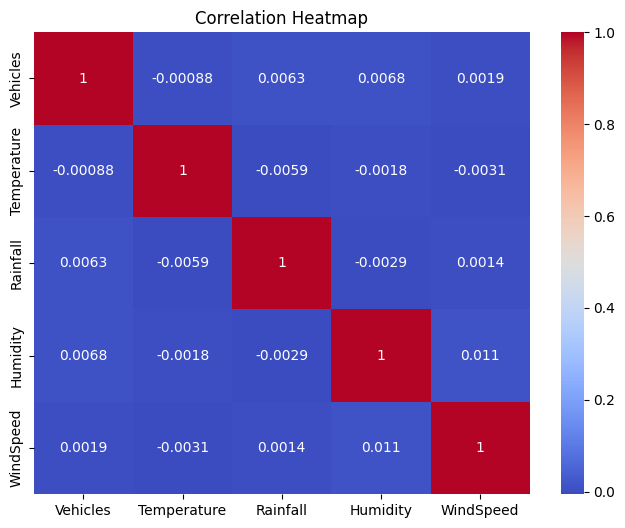

In [22]:
# CORRELATION ANALYSIS

correlation = df[
    [
        'Vehicles',
        'Temperature',
        'Rainfall',
        'Humidity',
        'WindSpeed'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

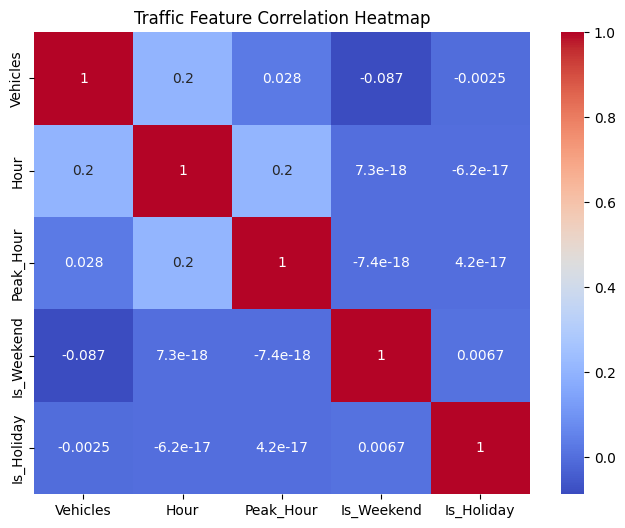

In [23]:
correlation = df[
    [
        'Vehicles',
        'Hour',
        'Peak_Hour',
        'Is_Weekend',
        'Is_Holiday'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Traffic Feature Correlation Heatmap")

plt.show()

In [20]:
# Increase traffic during events

df['Special_Event'] = np.random.choice(
    [0, 0, 0, 1],
    size=len(df)
)

# Increase vehicles during event rows

df.loc[
    df['Special_Event'] == 1,
    'Vehicles'
] = df.loc[
    df['Special_Event'] == 1,
    'Vehicles'
] + np.random.randint(10, 30)